In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# Part 1

In [6]:
np.random.seed(42)

def sample_geometric(p, n):
    np.random.seed(42)
    U = np.random.uniform(0, 1, n)
    return np.floor(np.log(U) / np.log(1 - p)).astype(int) + 1

p01 = sample_geometric(0.1, 10000)
p05 = sample_geometric(0.5, 10000)
p09 = sample_geometric(0.9, 10000)

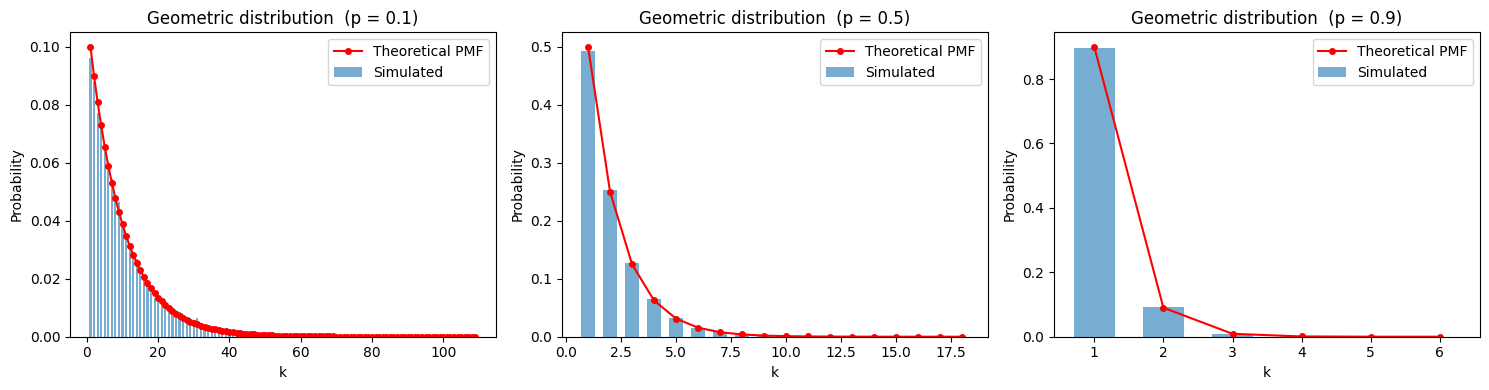

In [ ]:
def plot_geometric(samples, p, ax):
    k_max = samples.max() + 1
    k = np.arange(1, k_max + 1)
    pmf = (1 - p) ** (k - 1) * p 

    counts, _ = np.histogram(samples, bins=np.arange(1, k_max + 2) - 0.5)
    ax.bar(k, counts / len(samples), width=0.6, alpha=0.6, label="Simulated")
    ax.plot(k, pmf, "ro-", markersize=4, linewidth=1.5, label="Theoretical PMF")
    ax.set_title(f"Geometric distribution  (p = {p})")
    ax.set_xlabel("k")
    ax.set_ylabel("Probability")
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (samples, p) in zip(axes, [(p01, 0.1), (p05, 0.5), (p09, 0.9)]):
    plot_geometric(samples, p, ax)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import chisquare

def chi2_geometric(samples, p, min_expected=5):
    """Chi-square GoF test for Geometric(p), merging tail bins until E_i >= min_expected."""
    n = len(samples)
    k_max = int(samples.max())
    k_vals = np.arange(1, k_max + 1)
    pmf = (1 - p) ** (k_vals - 1) * p

    obs = np.array([np.sum(samples == k) for k in k_vals], dtype=float)
    exp = pmf * n

    obs_m, exp_m = list(obs), list(exp)
    while len(exp_m) > 1 and exp_m[-1] < min_expected:
        obs_m[-2] += obs_m[-1];  obs_m.pop()
        exp_m[-2] += exp_m[-1];  exp_m.pop()

    obs_arr = np.array(obs_m)
    exp_arr = np.array(exp_m)
    exp_arr = exp_arr / exp_arr.sum() * n

    stat, pval = chisquare(obs_arr, exp_arr)
    return stat, pval, len(obs_arr) - 1

print("Chi-square goodness-of-fit test — Geometric distribution (H0: samples ~ Geometric(p))")
print(f"{'p':>5}  {'χ² stat':>10}  {'df':>5}  {'p-value':>10}  {'Reject H0':>12}")
print("-" * 52)
for samples, p in [(p01, 0.1), (p05, 0.5), (p09, 0.9)]:
    stat, pval, df = chi2_geometric(samples, p)
    print(f"{p:>5}  {stat:>10.4f}  {df:>5}  {pval:>10.4f}  {'Yes' if pval < 0.05 else 'No':>12}")


Chi-square goodness-of-fit test — Geometric distribution (H0: samples ~ Geometric(p))
    p     χ² stat     df     p-value     Reject H0
----------------------------------------------------
  0.1     62.9708     71      0.7404            No
  0.5     15.0592     10      0.1299            No
  0.9      6.6497      3      0.0839            No


# Part 2

In [9]:
sixPointDist = {1: 7/48, 2: 5/48, 3: 1/8, 4: 1/16, 5: 1/4, 6: 5/16}

x_vals = np.array(list(sixPointDist.keys()))
p_vals = np.array(list(sixPointDist.values()))

## a) 

In [ ]:
def crude_method(x, p, n):
    F = np.cumsum(p)
    U = np.random.uniform(size=n)
    indices = np.searchsorted(F, U, side="left")
    return np.array(x)[indices]

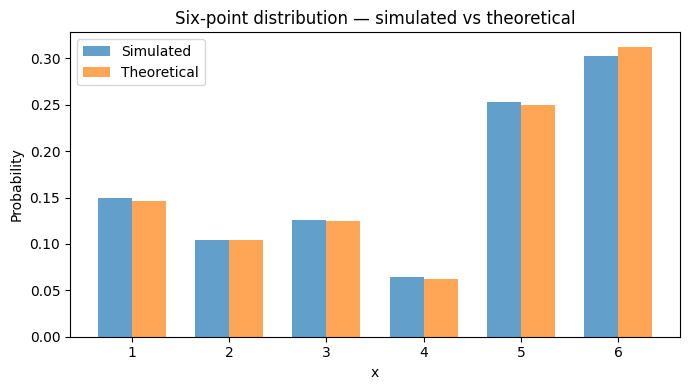

   x  Theoretical  Simulated
   1       0.1458     0.1499
   2       0.1042     0.1048
   3       0.1250     0.1255
   4       0.0625     0.0649
   5       0.2500     0.2527
   6       0.3125     0.3022


In [11]:
np.random.seed(42)

samples_6 = crude_method(x_vals, p_vals, n=10_000)

emp_pmf_6 = np.array([np.mean(samples_6 == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_6, width=width, alpha=0.7, label="Simulated")
ax.bar(x_vals + width/2, p_vals,    width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Six-point distribution — simulated vs theoretical")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'x':>4} {'Theoretical':>12} {'Simulated':>10}")
for xi, pt, ps in zip(x_vals, p_vals, emp_pmf_6):
    print(f"{xi:>4} {pt:>12.4f} {ps:>10.4f}")


## b) 

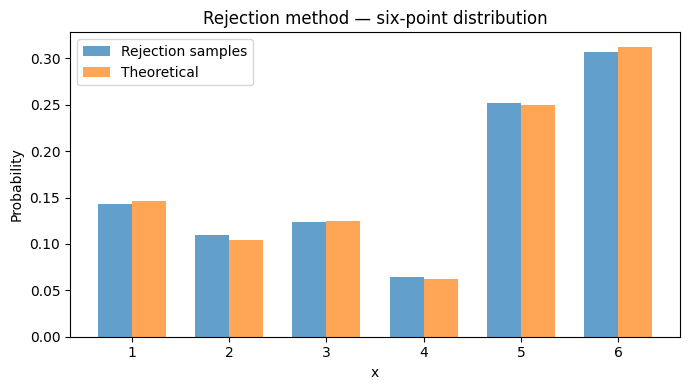

Expected trials per sample: 1.875


In [ ]:
# Rejection Method
def simple_rejection_method(x, p, n):
    k = len(x)
    c = np.max(p)
    samples = []
    while len(samples) < n:
        I  = int(np.floor(k * np.random.uniform()))
        U2 = np.random.uniform()
        if U2 <= p[I] / c:
            samples.append(x[I])
    return np.array(samples)


np.random.seed(42)
samples_rej = simple_rejection_method(x_vals, p_vals, n=10_000)
emp_pmf_rej = np.array([np.mean(samples_rej == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_rej, width=width, alpha=0.7, label="Rejection samples")
ax.bar(x_vals + width/2, p_vals,      width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Rejection method — six-point distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Expected trials per sample: {len(x_vals) * np.max(p_vals):.3f}")


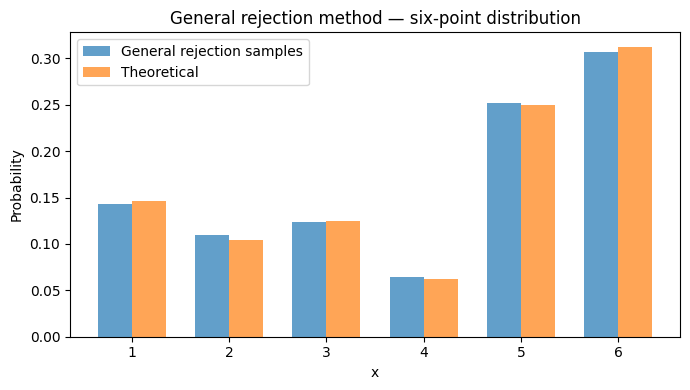

c = max(p_i/q_i) = 1.8750  (expected trials per sample)


In [ ]:
# general rejection
def rejection_method(p, q, sample_q, n):
    """
    p, q     : dicts {x: probability} for target and proposal pmfs (same support)
    sample_q : callable, returns one sample x ~ q
    n        : number of accepted samples to generate
    """
    c = max(p[x] / q[x] for x in p)

    samples = []
    while len(samples) < n:
        Y = sample_q()
        U = np.random.uniform()
        if U <= p[Y] / (c * q[Y]):
            samples.append(Y)
    return np.array(samples), c

np.random.seed(42)

qSixPointDist = {x: 1 / len(sixPointDist) for x in sixPointDist}

def sample_q():
    return np.random.choice(list(qSixPointDist.keys()), p=list(qSixPointDist.values()))

samples_genrej, c = rejection_method(sixPointDist, qSixPointDist, sample_q, n=10_000)
emp_pmf_genrej = np.array([np.mean(samples_genrej == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_genrej, width=width, alpha=0.7, label="General rejection samples")
ax.bar(x_vals + width/2, p_vals,         width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("General rejection method — six-point distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"c = max(p_i/q_i) = {c:.4f}  (expected trials per sample)")

## c) 

In [ ]:
# Alias Method

def alias_setup(p):
    n = len(p)
    L = list(range(n))                           
    F = list(np.array(p, dtype=float) * n)       

    G = [i for i, q in enumerate(F) if q >= 1]   
    S = [i for i, q in enumerate(F) if q <= 1]   

    while S:                           
        i = G[0]                       
        j = S[0]                       
        L[j] = i                       
        F[i] = F[i] - (1 - F[j])       
        if F[i] < 1 - 1e-9:            
            G.pop(0)
            S.append(i)
        S.pop(0)                       

    return np.clip(F, 0, 1), np.array(L, dtype=int)


def alias_sample(x, F, L, n):
    k = len(x)
    U1 = np.random.uniform(size=n)
    U2 = np.random.uniform(size=n)
    I  = np.floor(k * U1).astype(int)      
    picks = np.where(U2 <= F[I], I, L[I])
    return np.array(x)[picks]

Alias tables:
   i    x_i       F[i]       L[i]
   0      1     0.8750          5
   1      2     0.6250          5
   2      3     0.7500          5
   3      4     0.3750          6
   4      5     0.7500          6
   5      6     1.0000          6


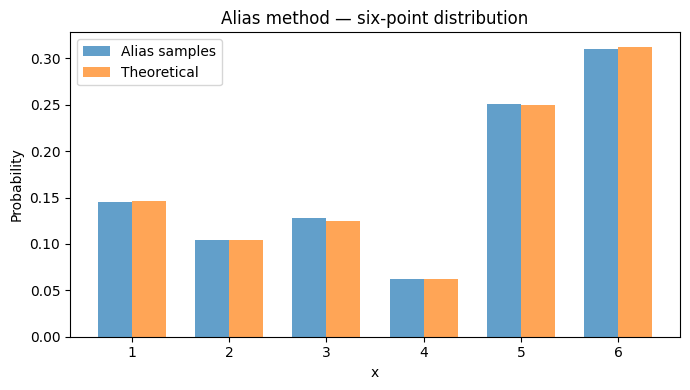

In [15]:
np.random.seed(42)

F_table, L_table = alias_setup(p_vals)

print("Alias tables:")
print(f"{'i':>4} {'x_i':>6} {'F[i]':>10} {'L[i]':>10}")
for i, (xi, f, l) in enumerate(zip(x_vals, F_table, L_table)):
    print(f"{i:>4} {xi:>6} {f:>10.4f} {x_vals[l]:>10}")

samples_alias = alias_sample(x_vals, F_table, L_table, n=10_000)
emp_pmf_alias = np.array([np.mean(samples_alias == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_alias, width=width, alpha=0.7, label="Alias samples")
ax.bar(x_vals + width/2, p_vals,        width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Alias method — six-point distribution")
ax.legend()
plt.tight_layout()
plt.show()


## Part 3

In [ ]:
import time
from scipy.stats import chi2

N    = 10000
REPS = 50
np.random.seed(0)

F_table, L_table = alias_setup(p_vals)

def time_method(fn, reps=REPS):
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps * 1e3

np.random.seed(42)
s_crude  = crude_method(x_vals, p_vals, N)
s_reject = simple_rejection_method(x_vals, p_vals, N)
s_alias  = alias_sample(x_vals, F_table, L_table, N)

t_crude  = time_method(lambda: crude_method(x_vals, p_vals, N))
t_reject = time_method(lambda: simple_rejection_method(x_vals, p_vals, N))
t_alias  = time_method(lambda: alias_sample(x_vals, F_table, L_table, N))

def chi2_result(samples):
    obs = np.array([np.sum(samples == xi) for xi in x_vals])
    stat, pval = chisquare(obs, p_vals * N)
    return stat, pval

chi_crude  = chi2_result(s_crude)
chi_reject = chi2_result(s_reject)
chi_alias  = chi2_result(s_alias)

print(f"{'Method':<20} {'Time (ms)':>10} {'χ² stat':>10} {'p-value':>10}  {'Reject H0?':>12}")
print("-" * 68)
for name, t, (stat, pval) in [
    ("Crude",     t_crude,  chi_crude),
    ("Rejection", t_reject, chi_reject),
    ("Alias",     t_alias,  chi_alias),
]:
    reject = "Yes" if pval < 0.05 else "No"
    print(f"{name:<20} {t:>10.2f} {stat:>10.3f} {pval:>10.4f}  {reject:>12}")
    
crit_val = chi2.ppf(1 - 0.05, df=len(x_vals)-1)
print(f"\nChi^2 critical value (df={len(x_vals)-1}, alpha=0.05): {crit_val:.3f}")
print(f"H0: samples follow the theoretical distribution.")
print(f"Fail to reject H0 (p > 0.05) → method produces the correct distribution.")

k = len(x_vals)
c = np.max(p_vals)
print(f"\nRejection, expected trials per sample: k·c = {k}·{c:.4f} = {k*c:.3f}")


Method                Time (ms)    χ² stat    p-value    Reject H0?
--------------------------------------------------------------------
Crude                      0.17      5.801     0.3261            No
Rejection                 74.63      3.134     0.6793            No
Alias                      0.23      0.917     0.9690            No

Chi^2 critical value (df=5, alpha=0.05): 11.070
H0: samples follow the theoretical distribution.
Fail to reject H0 (p > 0.05) → method produces the correct distribution.

Rejection, expected trials per sample: k·c = 6·0.3125 = 1.875


## Part 4 - Recommendations

### Crude Method
How it works: Build the CDF, draw $U \sim \mathcal{U}(0,1)$, return $x_i$ at the first CDF step that exceeds $U$.

**Speed:** $O(\log k)$ per sample (binary search). Fast for small $k$; slows as $k$ grows. 

**Setup:** $O(k)$, just cumsum. Negligible.

**Memory:** $O(k)$ for the CDF array.

**Use when:** $k$ is small-to-moderate, the distribution changes between batches (no amortisation of setup), or simplicity is the priority.


### Rejection Method
**How it works:** Draw a candidate index $I$ uniformly, accept with probability $p_I / c$; repeat until accepted.


**Speed:** Expected $k \cdot c$ trials per sample. With $c = \max(p_i)$, cost grows when one $p_i \gg$ others.

**Setup:** $O(1)$, just compute $c = \max(p)$.

**Memory:** $O(1)$ extra, only needs the $p$ array.

**Use when:** $k$ is small and probabilities are roughly uniform (low rejection rate). 

**Avoid:** when one probability dominates — a high $c$ means many rejections and poor efficiency.


### Alias Method
**How it works:** Pre-process $p$ into tables $F$ and $L$ of size $k$. Each sample needs exactly two uniforms and one comparison, $O(1)$.

**Speed:** $O(1)$ per sample after setup. Fully vectorisable, fastest for large $N$.

**Setup:** $O(k)$, build $F$ and $L$ tables once. 

**Memory:** $O(k)$, for $F$ and $L$. 

**Use when:** generating a very large number of samples from a fixed distribution. The $O(k)$ setup cost is quickly amortised — the alias method is the standard choice in high-performance simulation.


### Summary table

| Criterion | Crude | Rejection | Alias |
|---|:---:|:---:|:---:|
| Per-sample cost | $O(\log k)$ | $O(k \cdot c)$ variable | $O(1)$ |
| Setup cost | $O(k)$ | $O(1)$ | $O(k)$ |
| Memory | $O(k)$ | $O(1)$ | $O(k)$ |